In [51]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors

#数据准备
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam[left_index:right_index]#±1.5A

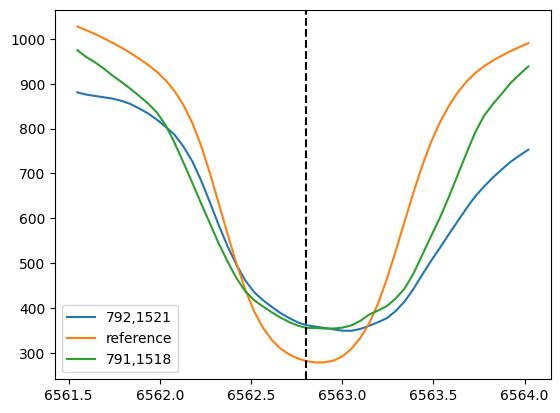

In [52]:
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
plt.plot(lam,rsm[1].data[left_index:right_index,792,1521],label='792,1521')
plt.plot(lam,I0,label='reference')
plt.plot(lam,rsm[1].data[left_index:right_index,791,1518],label='791,1518')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

In [11]:
def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

SL=356.23,初值是684.17,范围是[0.00,20000.00], SU=877.19,初值是684.17,范围是[0.00,20000.00]
tau0L=12.07,初值是0.20,范围是[0.00,100.00], tau0U=4.26,初值是0.20,范围是[0.00,100.00]
vL=-120.00,初值是20.00,范围是[-120.00,100.00], vU=-55.34,初值是-20.00,范围是[-100.00,100.00]
WL=2.11,初值是0.50,范围是[0.01,10.00], WU=0.52,初值是0.50,范围是[0.01,10.00]
拟合误差: 36.07465702697248


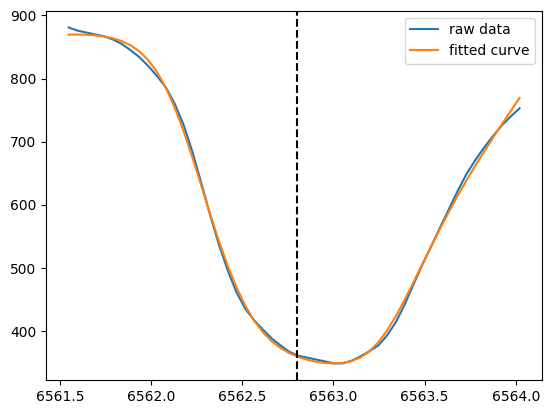

In [57]:
#I=rsm[1].data[50:90,795,1521]
I=rsm[1].data[left_index:right_index,792,1521]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=20,-120,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-20,-100,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

yfit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-yfit)**2)/len(I))

In [71]:
import numpy as np
from scipy.optimize import differential_evolution
from functools import partial

# 原来的模型函数 double_cloud(lam, SL, SU, tau0L, tau0U, vL, vU, WL, WU, I0)
# 这里用 partial 固定 I0
double_cloud_par = partial(double_cloud, I0=I0)

# 定义目标函数（残差平方和）
def objective(params, lam, I):
    model_vals = double_cloud_par(lam, *params)
    return np.sum((I - model_vals)**2/len(I))
    
# 定义参数边界（对应 curve_fit 的 bounds）
bounds = list(zip(paras2[1,:], paras2[2,:]))

# 全局优化
result = differential_evolution(objective, bounds, args=(lam, I), maxiter=2000)
# Step 1: DE 全局搜索
result = differential_evolution(objective, bounds, args=(lam, I), maxiter=1000)
popt_global = result.x
print("全局搜索结果:", popt_global)
# Step 2: 用 DE 的结果作为初值，再局部精修
popt2, pcov2 = curve_fit(double_cloud_par, lam, I, p0=popt_global,
                         bounds=(paras2[1,:], paras2[2,:]), maxfev=5000)



# 输出拟合结果
SL_fit, SU_fit, tau0L_fit, tau0U_fit, vL_fit, vU_fit, WL_fit, WU_fit = popt2

print("最优参数:", popt2)
yfit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-yfit)**2)/len(I))


全局搜索结果: [ 812.99823642  326.08478504    1.66370914    1.01200298 -120.
   18.29238733    1.86578613    0.81850035]
最优参数: [ 812.97228845  326.07593024    1.66319797    1.01195691 -119.99999999
   18.29312598    1.86599254    0.81849061]
拟合误差: 95.99195239786378


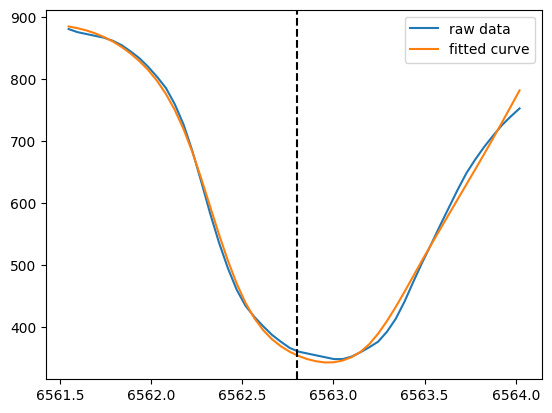

In [68]:
#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()
